# Gen Z Social Media Usage — EDA

Dataset: [sharmajicoder/gen-z-social-media-usage-dataset](https://www.kaggle.com/datasets/sharmajicoder/gen-z-social-media-usage-dataset) (`genz_social_media_usage_1M.csv`).


In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import kagglehub
from IPython.display import display
from scipy import stats

sns.set_theme(style="white")
plt.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "axes.edgecolor": "#d0d7de",
        "axes.labelcolor": "#24292f",
        "axes.titlecolor": "#24292f",
        "text.color": "#24292f",
        "xtick.color": "#57606a",
        "ytick.color": "#57606a",
        "grid.color": "#d8dee4",
        "grid.linewidth": 0.6,
        "grid.alpha": 0.55,
        "figure.titlesize": 14,
        "axes.titlesize": 13,
        "axes.labelsize": 11,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "figure.figsize": (11, 5),
    }
)

CAT_PALETTE = ["#58d5d8", "#a371f7", "#f577a1", "#79c0ff", "#ffa657"]
SEQ_CMAP = sns.color_palette("mako", as_cmap=True)

CSV_BASENAME = "genz_social_media_usage_1M.csv"
KAGGLE_SLUG = "sharmajicoder/gen-z-social-media-usage-dataset"
SAMPLE_N = 50_000
SAMPLE_RS = 7

EXPECTED_COLS = [
    "age",
    "gender",
    "country",
    "daily_usage_hours",
    "primary_platform",
    "num_platforms_used",
    "purpose",
    "avg_session_minutes",
    "night_usage",
    "mental_health_score",
    "addiction_level",
    "screen_time_before_sleep",
]


def resolve_csv_path() -> Path:
    kaggle_root = Path("/kaggle/input")
    if kaggle_root.exists():
        for p in kaggle_root.rglob(CSV_BASENAME):
            assert p.is_file()
            return p
        csvs = sorted(kaggle_root.rglob("*.csv"))
        assert len(csvs) == 1, f"expected 1 csv under /kaggle/input, got {len(csvs)}"
        return csvs[0]
    local_data = Path("data") / CSV_BASENAME
    if local_data.exists():
        return local_data
    root = Path(kagglehub.dataset_download(KAGGLE_SLUG))
    p = root / CSV_BASENAME
    if p.exists():
        return p
    csvs = sorted(root.rglob("*.csv"))
    assert len(csvs) == 1, f"expected 1 csv in dataset folder, got {len(csvs)}: {csvs}"
    return csvs[0]


def bar_counts_pct(
    ax: plt.Axes,
    s: pd.Series,
    title: str,
    order: list[str] | None = None,
    palette: list[str] | None = None,
    rotate: int = 18,
) -> None:
    vc = s.value_counts()
    if order is not None:
        vc = vc.reindex([x for x in order if x in vc.index])
    if palette is None:
        palette = CAT_PALETTE
    idx = vc.index.astype(str)
    bars = ax.bar(idx, vc.values, color=palette[: len(vc)], edgecolor="#30363d", linewidth=0.8)
    ax.set_title(title)
    ax.set_ylabel("count")
    total = int(vc.sum())
    for b in bars:
        h = b.get_height()
        pct = 100.0 * h / total
        ax.text(
            b.get_x() + b.get_width() / 2,
            h,
            f"{int(h):,}\n({pct:.1f}%)",
            ha="center",
            va="bottom",
            fontsize=8,
            color="#24292f",
        )
    ax.tick_params(axis="x", rotation=rotate)


def chi2_report(name: str, table: pd.DataFrame) -> None:
    chi2, dof, pval, _ = stats.chi2_contingency(table, correction=False)
    print(f"{name}: chi2={chi2:.3f}, dof={dof}, p={pval:.4g}")


csv_path = resolve_csv_path()
print("CSV:", csv_path)

df = pd.read_csv(csv_path, low_memory=False)
missing_cols = set(EXPECTED_COLS) - set(df.columns)
assert not missing_cols, f"missing columns: {sorted(missing_cols)}"
extra = set(df.columns) - set(EXPECTED_COLS)
assert not extra, f"unexpected columns: {sorted(extra)}"
assert df.shape[0] > 0 and df.shape[1] == len(EXPECTED_COLS)

assert set(df["night_usage"].unique()) == {0, 1}
assert set(df["addiction_level"].unique()) == {"Low", "Medium", "High"}

df_s = df.sample(SAMPLE_N, random_state=SAMPLE_RS)

print(df.shape[0], "rows ×", df.shape[1], "cols")
print(f"Plot sample: {SAMPLE_N} rows (random_state={SAMPLE_RS})")
print("\nRandom peek (5 rows):")
display(df.sample(5, random_state=SAMPLE_RS))
print("\ndtypes:")
display(df.dtypes)
print("\nNumeric summary:")
display(df.describe(include=[np.number]))
print("\nCategorical summary:")
display(df.describe(include=["object"]))


CSV: /kaggle/input/datasets/sharmajicoder/gen-z-social-media-usage-dataset/genz_social_media_usage_1M.csv
1000000 rows × 12 cols
Plot sample: 50000 rows (random_state=7)

Random peek (5 rows):


,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
330111,18,Female,India,2.666985,TikTok,4,Entertainment,17.605890,0,6.959075,Medium,28.320342
663520,18,Female,India,1.006012,TikTok,2,Entertainment,25.763139,0,7.669403,Low,24.400893
525009,19,Female,India,2.965354,Instagram,3,Entertainment,29.218908,1,6.632572,Medium,36.329353
199449,17,Female,Australia,2.048886,Instagram,1,Socializing,29.304700,1,7.056110,Low,57.673760
978049,24,Female,UK,2.979517,Twitter,5,Socializing,5.000000,1,7.767625,Medium,15.654089



dtypes:


age                           int64
gender                       object
country                      object
daily_usage_hours           float64
primary_platform             object
num_platforms_used            int64
purpose                      object
avg_session_minutes         float64
night_usage                   int64
mental_health_score         float64
addiction_level              object
screen_time_before_sleep    float64
dtype: object


Numeric summary:


,age,daily_usage_hours,num_platforms_used,avg_session_minutes,night_usage,mental_health_score,screen_time_before_sleep
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,19.994629,3.514998,2.999469,25.088819,0.599958,7.170671,40.120754
std,4.322119,1.468771,1.414598,9.794249,0.489907,1.503885,19.569847
min,13.000000,0.500000,1.000000,5.000000,0.000000,1.000000,0.000000
25%,16.000000,2.493985,2.000000,18.257267,0.000000,6.147371,26.459592
50%,20.000000,3.503302,3.000000,25.002480,1.000000,7.198098,39.977162
75%,24.000000,4.513016,4.000000,31.759257,1.000000,8.243818,53.424345
max,27.000000,10.000000,5.000000,80.262224,1.000000,10.000000,137.998719



Categorical summary:


,gender,country,primary_platform,purpose,addiction_level
count,1000000,1000000,1000000,1000000,1000000
unique,3,7,5,5,3
top,Female,India,Instagram,Entertainment,Medium
freq,480113,350321,299927,400052,589843


## 1 — Univariate


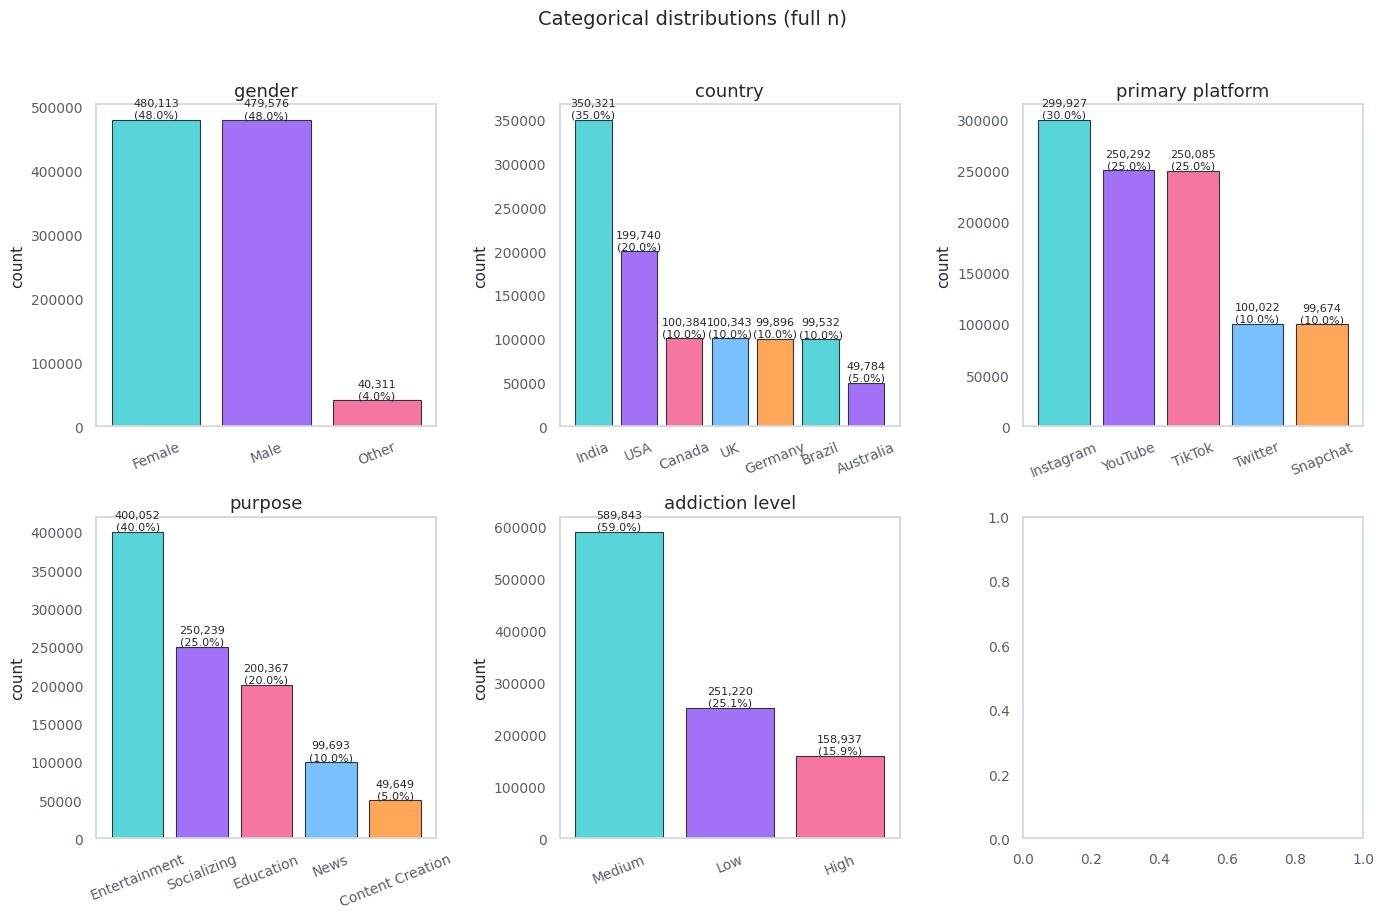

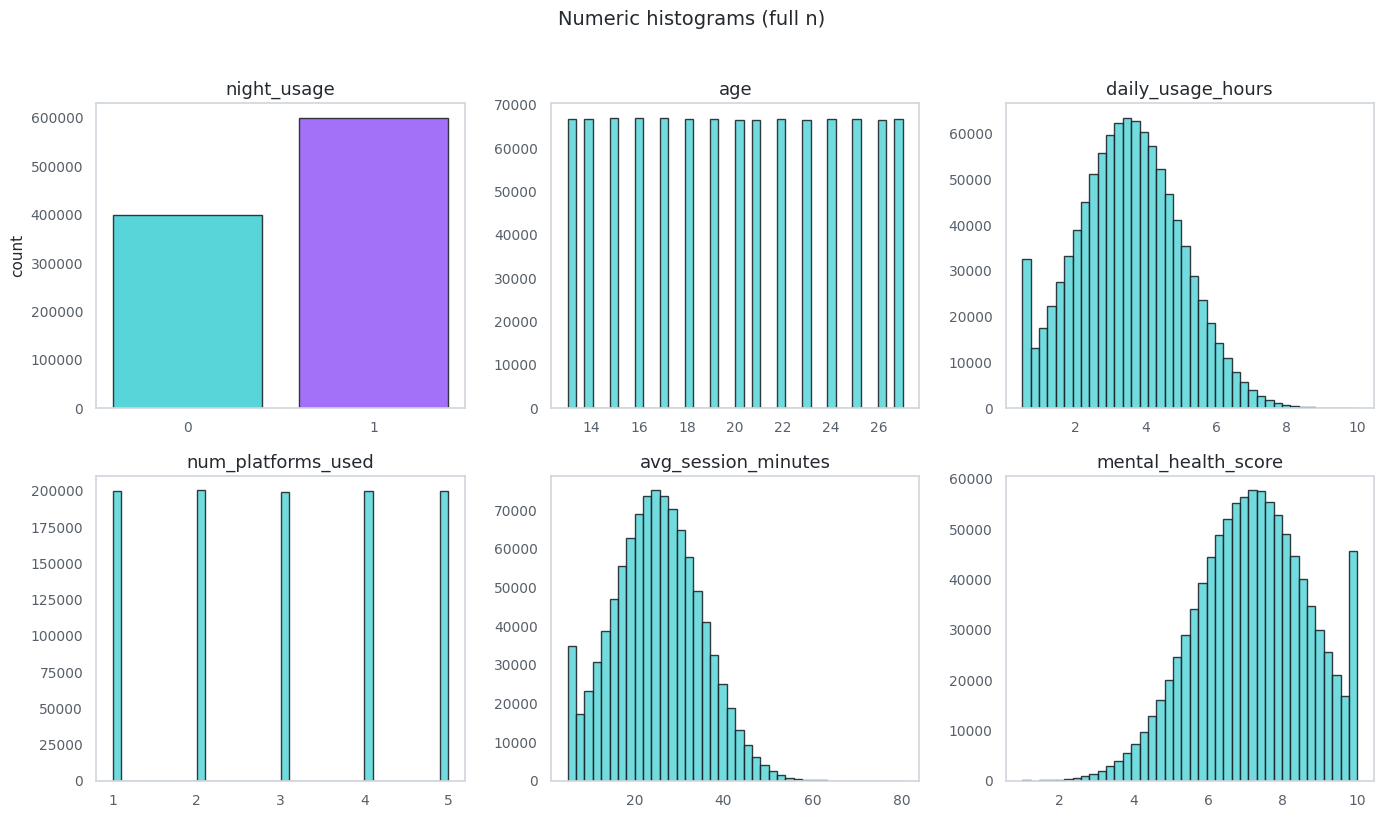

Takeaways — Univariate: Check bar heights for heavy 'Other' buckets on geography/platform/purpose if present; mental_health_score right tail / top mass suggests pile-up near max; night_usage is binary; addiction_level is Low/Medium/High with Medium largest.


In [2]:
cat_cols = ["gender", "country", "primary_platform", "purpose", "addiction_level"]
num_cols = ["age", "daily_usage_hours", "num_platforms_used", "avg_session_minutes", "mental_health_score", "screen_time_before_sleep"]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
axes = axes.ravel()
for i, c in enumerate(cat_cols):
    bar_counts_pct(axes[i], df[c], c.replace("_", " "), rotate=22)
fig.suptitle("Categorical distributions (full n)", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.ravel()
axes[0].bar(["0", "1"], df["night_usage"].value_counts().reindex([0, 1]).values, color=CAT_PALETTE[:2], edgecolor="#30363d")
axes[0].set_title("night_usage")
axes[0].set_ylabel("count")
for ax, c in zip(axes[1:], num_cols):
    ax.hist(df[c], bins=40, color="#58d5d8", edgecolor="#161b22", alpha=0.85)
    ax.set_title(c)
fig.suptitle("Numeric histograms (full n)", y=1.02)
plt.tight_layout()
plt.show()

print(
    "Takeaways — Univariate: "
    "Check bar heights for heavy 'Other' buckets on geography/platform/purpose if present; "
    "mental_health_score right tail / top mass suggests pile-up near max; "
    "night_usage is binary; addiction_level is Low/Medium/High with Medium largest."
)


## 2 — Multivariate


primary_platform × purpose: chi2=15.195, dof=0.5103800232687528, p=16


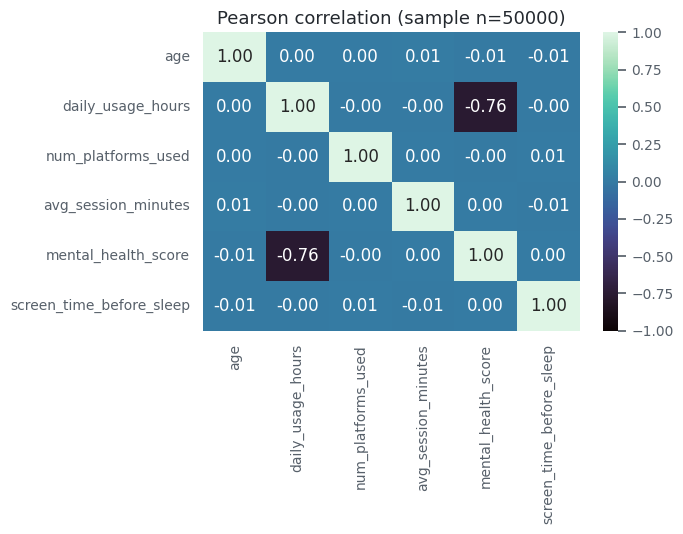

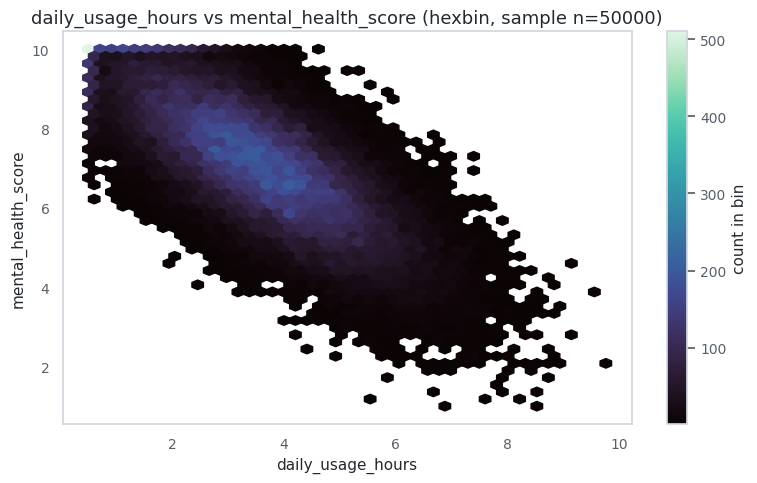

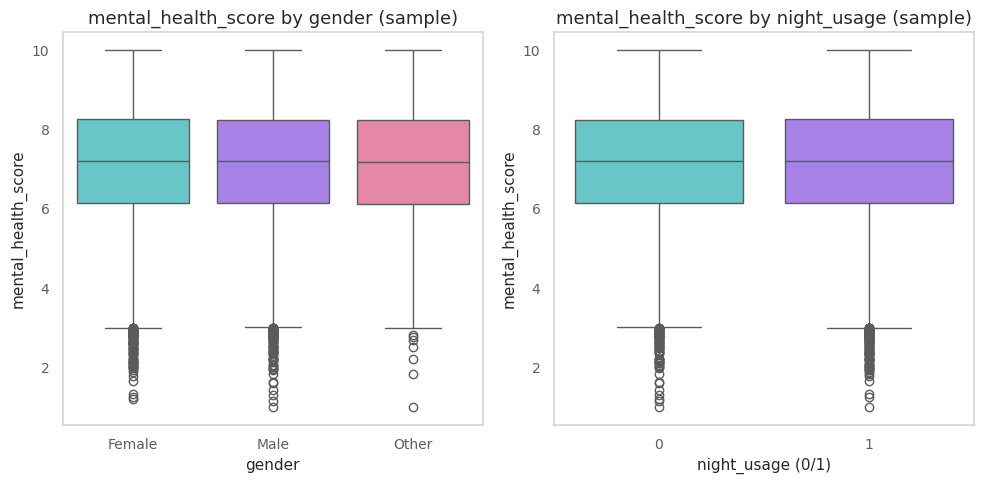

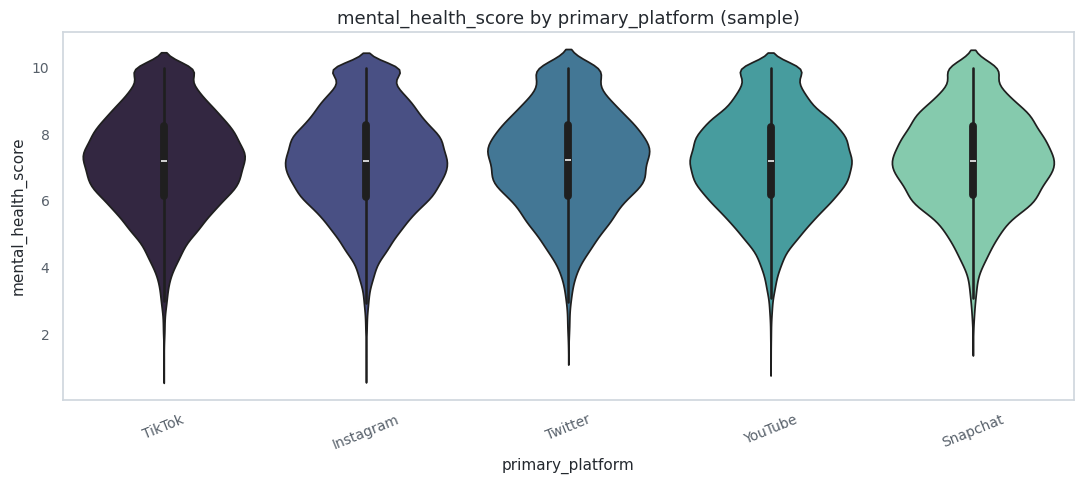

Takeaways — Multivariate: chi² tests independence of platform vs purpose at huge n (tiny effects can be significant); row-share heatmap shows composition within platform; correlation matrix is on SAMPLE only; box/violin layers compare mental_health_score across gender, night_usage, platform.


In [3]:
ct_pp_purpose = pd.crosstab(df["primary_platform"], df["purpose"])
chi2_report("primary_platform × purpose", ct_pp_purpose)

# plt.figure(figsize=(10, 5))
# sns.heatmap(ct_pp_purpose.div(ct_pp_purpose.sum(axis=1), axis=0), cmap=SEQ_CMAP, annot=False)
# plt.title("primary_platform × purpose — row shares (full n)")
# plt.ylabel("primary_platform")
# plt.xlabel("purpose")
# plt.tight_layout()
# plt.show()

num_for_corr = [
    "age",
    "daily_usage_hours",
    "num_platforms_used",
    "avg_session_minutes",
    "mental_health_score",
    "screen_time_before_sleep",
]
cm = df_s[num_for_corr].corr()
plt.figure(figsize=(7, 5.5))
sns.heatmap(cm, cmap="mako", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f")
plt.title(f"Pearson correlation (sample n={SAMPLE_N})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hexbin(
    df_s["daily_usage_hours"],
    df_s["mental_health_score"],
    gridsize=45,
    cmap="mako",
    mincnt=1,
)
plt.colorbar(label="count in bin")
plt.xlabel("daily_usage_hours")
plt.ylabel("mental_health_score")
plt.title(f"daily_usage_hours vs mental_health_score (hexbin, sample n={SAMPLE_N})")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    data=df_s,
    x="gender",
    y="mental_health_score",
    hue="gender",
    palette=CAT_PALETTE[:3],
    legend=False,
)
plt.title("mental_health_score by gender (sample)")
plt.subplot(1, 2, 2)
sns.boxplot(
    data=df_s,
    x="night_usage",
    y="mental_health_score",
    hue="night_usage",
    palette=CAT_PALETTE[:2],
    legend=False,
)
plt.xlabel("night_usage (0/1)")
plt.title("mental_health_score by night_usage (sample)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 5))
sns.violinplot(
    data=df_s,
    x="primary_platform",
    y="mental_health_score",
    hue="primary_platform",
    palette="mako",
    legend=False,
)
plt.xticks(rotation=22)
plt.title("mental_health_score by primary_platform (sample)")
plt.tight_layout()
plt.show()

print(
    "Takeaways — Multivariate: "
    "chi² tests independence of platform vs purpose at huge n (tiny effects can be significant); "
    "row-share heatmap shows composition within platform; "
    "correlation matrix is on SAMPLE only; "
    "box/violin layers compare mental_health_score across gender, night_usage, platform."
)
